In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
df = pd.read_csv("/content/drive/MyDrive/Practice/recipe_site_traffic_2212 (1).csv")

In [ ]:
df.shape

(947, 8)

In [ ]:
df.value_counts()

,,,,,,,,count
recipe,calories,carbohydrate,sugar,protein,category,servings,high_traffic,
946,266.61,35.77,0.97,8.07,Potato,6,High,1
2,35.48,38.56,0.66,0.92,Potato,4,High,1
4,97.03,30.56,38.63,0.02,Beverages,4,High,1
6,691.15,3.46,1.65,53.93,One Dish Meal,2,High,1
9,538.52,3.78,3.37,3.79,Pork,6,High,1
...,...,...,...,...,...,...,...,...
21,9.26,17.44,8.16,10.81,Potato,6,High,1
19,1090.75,4.65,0.69,3.49,Meat,6,High,1
18,1695.82,0.10,0.39,33.17,Meat,1,High,1


In [ ]:
df.isnull().sum()

,0
recipe,0
calories,52
carbohydrate,52
sugar,52
protein,52
category,0
servings,0
high_traffic,373


In [ ]:

# ---- recipe: unique identifier ----
print("recipe — duplicates:", df['recipe'].duplicated().sum(), "| missing:", df['recipe'].isna().sum())
df = df.set_index('recipe')



recipe — duplicates: 0 | missing: 0


In [ ]:
# ---- calories, carbohydrate, sugar, protein: numeric, missing together ----
num_cols = ['calories', 'carbohydrate', 'sugar', 'protein']
print("\nNutrition columns missing before cleaning:")
print(df[num_cols].isna().sum())

for c in num_cols:
    df[c] = df.groupby('category')[c].transform(lambda x: x.fillna(x.median()))

print("\nNutrition columns missing after cleaning:")
print(df[num_cols].isna().sum())




Nutrition columns missing before cleaning:
calories        52
carbohydrate    52
sugar           52
protein         52
dtype: int64

Nutrition columns missing after cleaning:
calories        0
carbohydrate    0
sugar           0
protein         0
dtype: int64


In [ ]:
# ---- category: documented as 10 groups, but 11 found ----
print("\ncategory — unique before fix:", df['category'].nunique(), "(should be 10)")
df['category'] = df['category'].replace({'Chicken Breast': 'Chicken'})
print("category — unique after fix:", df['category'].nunique())



category — unique before fix: 11 (should be 10)
category — unique after fix: 10


In [ ]:
# ---- servings: stored as text, e.g. '4 as a snack' ----
print("\nservings — dtype before fix:", df['servings'].dtype)
# df['servings'] = df['servings'].str.extract(r'(\d+)').astype(int) # This line is removed as servings is already int64
print("servings — dtype after fix:", df['servings'].dtype)


servings — dtype before fix: int64
servings — dtype after fix: int64


In [ ]:
# ---- high_traffic: only 'High' or missing -> binary target ----
print("\nhigh_traffic — missing before fix:", df['high_traffic'].isna().sum())
df['high_traffic'] = df['high_traffic'].fillna('Low')
df['high_traffic'] = (df['high_traffic'] == 'High').astype(int)
print("high_traffic — class balance after fix:")
print(df['high_traffic'].value_counts(normalize=True))


high_traffic — missing before fix: 373
high_traffic — class balance after fix:
high_traffic
1    0.606125
0    0.393875
Name: proportion, dtype: float64


In [ ]:
# ---- final check ----
print("\nFinal missing values check:")
print(df.isna().sum())
print("\nFinal shape:", df.shape)
df.head()


Final missing values check:
calories        0
carbohydrate    0
sugar           0
protein         0
category        0
servings        0
high_traffic    0
dtype: int64

Final shape: (947, 7)


,calories,carbohydrate,sugar,protein,category,servings,high_traffic
recipe,,,,,,,
1,399.26,19.56,5.23,29.82,Pork,6,1
2,35.48,38.56,0.66,0.92,Potato,4,1
3,914.28,42.68,3.09,2.88,Breakfast,1,0
4,97.03,30.56,38.63,0.02,Beverages,4,1
5,27.05,1.85,0.80,0.53,Beverages,4,0


In [ ]:
df.describe()

,calories,carbohydrate,sugar,protein,servings,high_traffic
count,947.000000,947.000000,947.000000,947.000000,947.000000,947.000000
mean,431.056241,34.454947,8.887598,23.957212,3.477297,0.606125
std,441.370267,42.844746,14.372359,35.479461,1.732741,0.488866
min,0.140000,0.030000,0.010000,0.000000,1.000000,0.000000
25%,114.410000,9.135000,1.795000,3.465000,2.000000,0.000000
50%,296.920000,21.190000,4.400000,11.240000,4.000000,1.000000
75%,576.225000,42.590000,9.565000,29.820000,4.000000,1.000000
max,3633.160000,530.420000,148.750000,363.360000,6.000000,1.000000


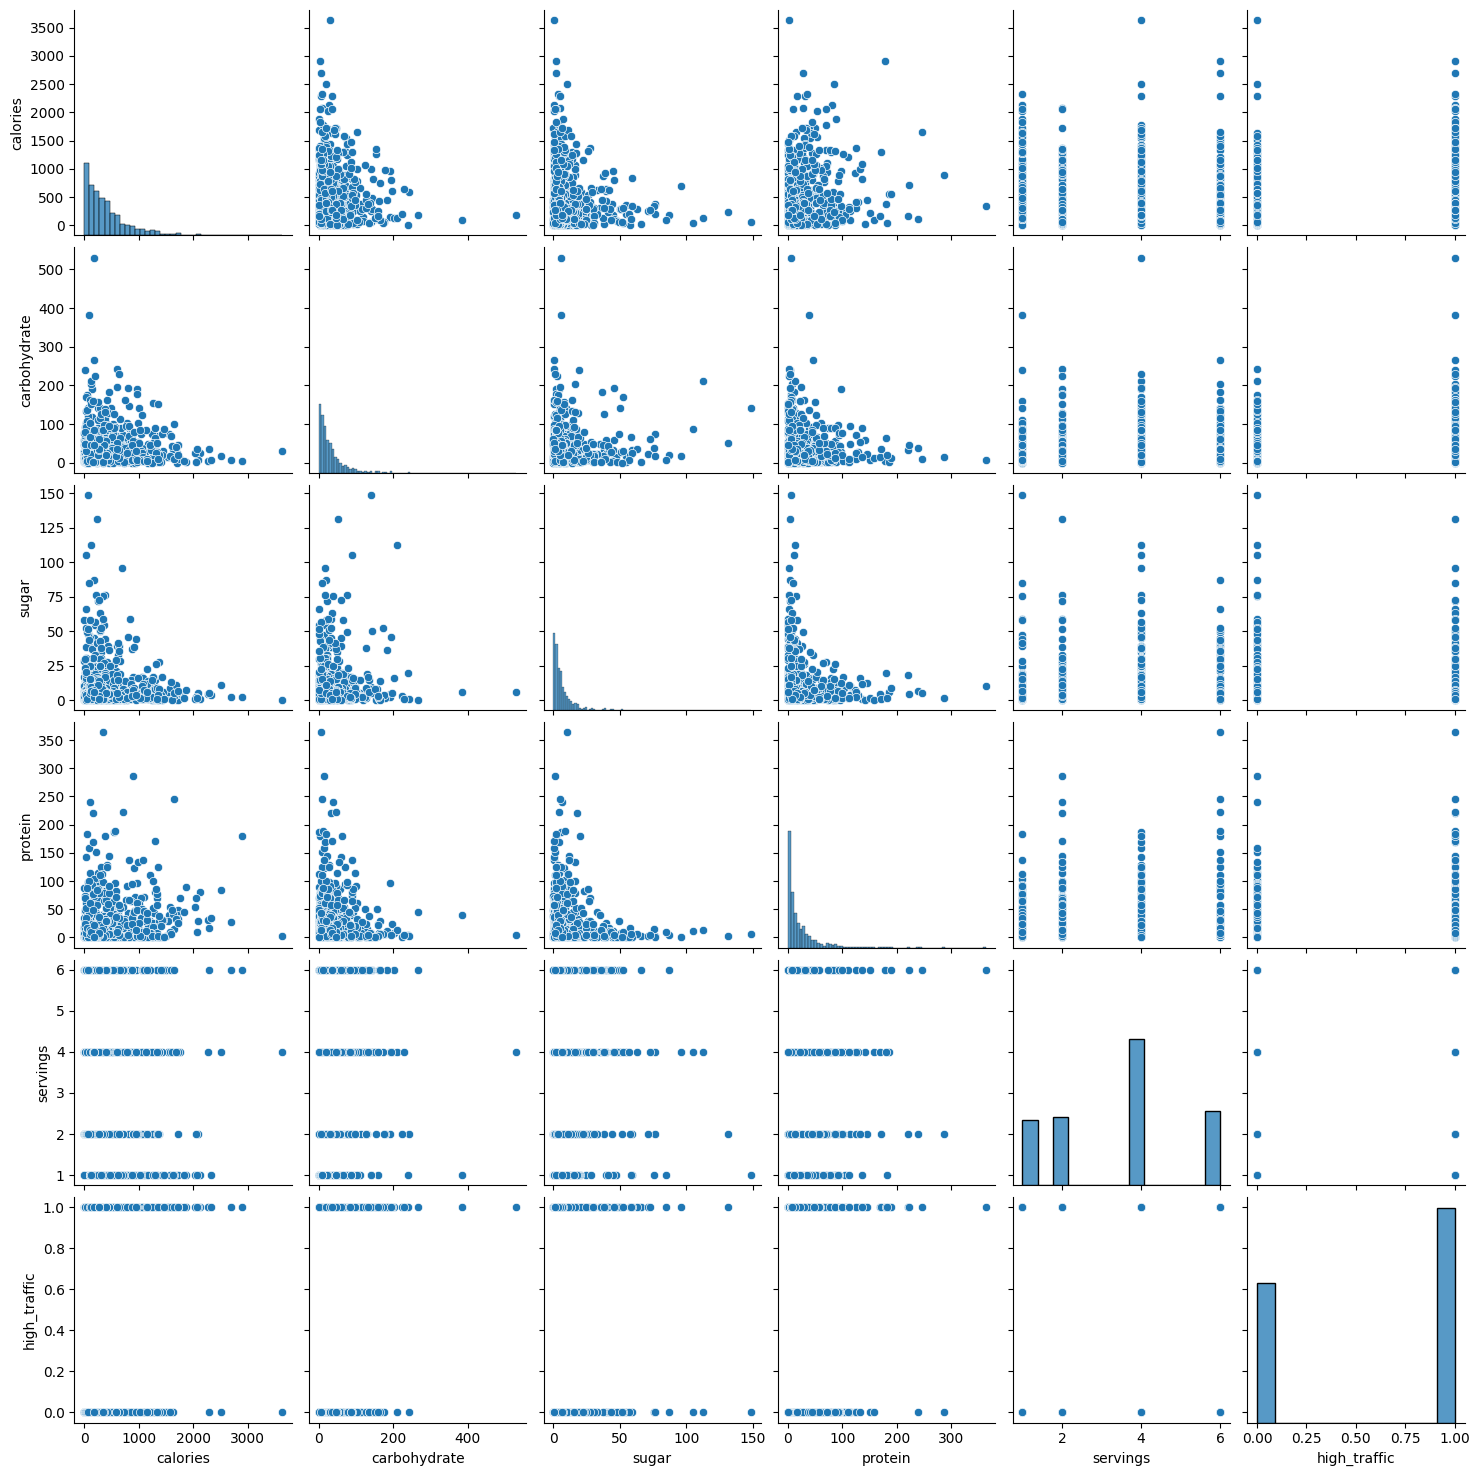

In [ ]:
sns.pairplot(df)

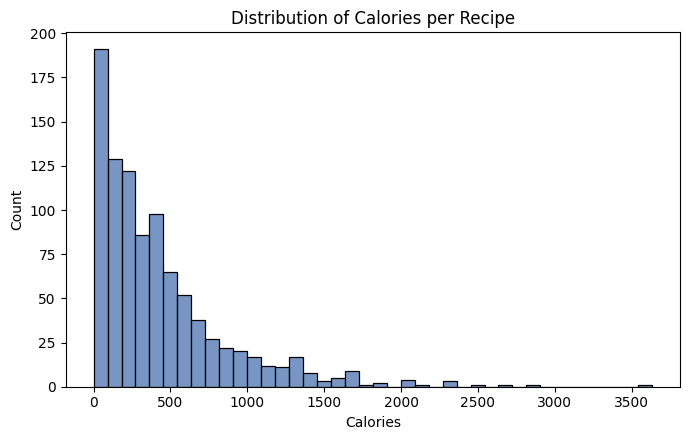

In [ ]:
fig, ax = plt.subplots(figsize=(7,4.5))
sns.histplot(df['calories'], bins=40, color='#4C72B0', ax=ax)
ax.set_title('Distribution of Calories per Recipe')
ax.set_xlabel('Calories')
plt.tight_layout()
plt.show()

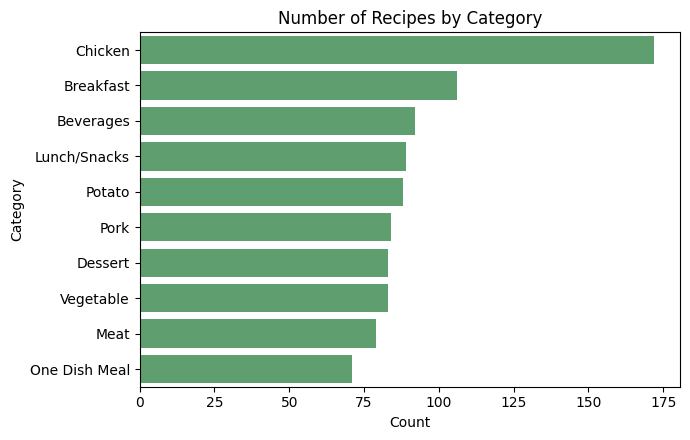

In [ ]:
order = df['category'].value_counts().index
fig, ax = plt.subplots(figsize=(7,4.5))
sns.countplot(y='category', data=df, order=order, color='#55A868', ax=ax)
ax.set_title('Number of Recipes by Category')
ax.set_xlabel('Count')
ax.set_ylabel('Category')
plt.tight_layout()
plt.show()

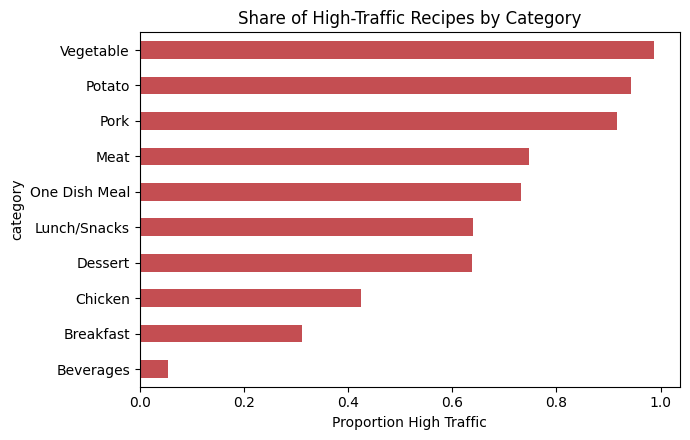

,high_traffic
category,
Vegetable,0.987952
Potato,0.943182
Pork,0.916667
Meat,0.746835
One Dish Meal,0.732394
Lunch/Snacks,0.640449
Dessert,0.638554
Chicken,0.424419
Breakfast,0.311321


In [ ]:
rate = df.groupby('category')['high_traffic'].mean().sort_values(ascending=False)
fig, ax = plt.subplots(figsize=(7,4.5))
rate.plot(kind='barh', color='#C44E52', ax=ax)
ax.set_title('Share of High-Traffic Recipes by Category')
ax.set_xlabel('Proportion High Traffic')
ax.invert_yaxis()
plt.tight_layout()
plt.show()
rate

/tmp/ipykernel_833/1042511606.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='high_traffic', y='sugar', data=df, ax=ax, palette=['#8172B2','#CCB974'])
/tmp/ipykernel_833/1042511606.py:3: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(['Low/Not High', 'High'])


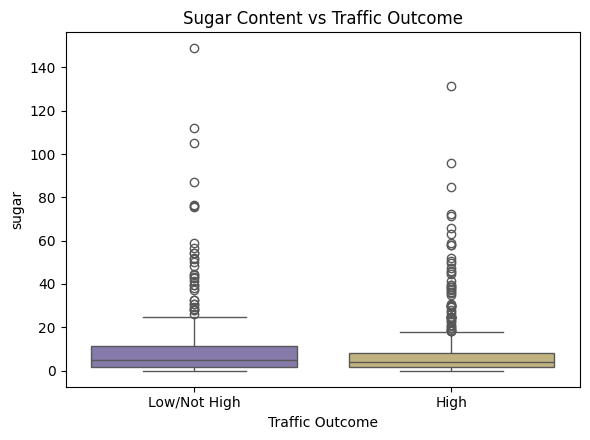

,calories,carbohydrate,sugar,protein
high_traffic,,,,
0,282.57,18.84,4.930,9.62
1,313.92,22.55,4.165,12.52


In [ ]:
fig, ax = plt.subplots(figsize=(6,4.5))
sns.boxplot(x='high_traffic', y='sugar', data=df, ax=ax, palette=['#8172B2','#CCB974'])
ax.set_xticklabels(['Low/Not High', 'High'])
ax.set_title('Sugar Content vs Traffic Outcome')
ax.set_xlabel('Traffic Outcome')
plt.tight_layout()
plt.show()

df.groupby('high_traffic')[['calories','carbohydrate','sugar','protein']].median()

In [ ]:
from sklearn.model_selection import train_test_split, cross_validate
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                              confusion_matrix, RocCurveDisplay)

In [ ]:
X = df.drop(columns=['high_traffic'])
y = df['high_traffic']

num_features = ['calories', 'carbohydrate', 'sugar', 'protein', 'servings']
cat_features = ['category']

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

preprocess = ColumnTransformer([
    ('num', StandardScaler(), num_features),
    ('cat', OneHotEncoder(handle_unknown='ignore'), cat_features)
])

In [ ]:
baseline = Pipeline([('prep', preprocess),
                      ('clf', LogisticRegression(max_iter=1000, random_state=42))])
baseline.fit(X_train, y_train)

rf = Pipeline([('prep', preprocess),
               ('clf', RandomForestClassifier(n_estimators=300, max_depth=6, random_state=42))])
rf.fit(X_train, y_train)

print("Both models fitted.")

Both models fitted.


In [ ]:
pred_b = baseline.predict(X_test)
proba_b = baseline.predict_proba(X_test)[:,1]
pred_r = rf.predict(X_test)
proba_r = rf.predict_proba(X_test)[:,1]

def report(name, y_true, y_pred):
    print(f"--- {name} ---")
    print("Accuracy :", round(accuracy_score(y_true,y_pred),3))
    print("Precision:", round(precision_score(y_true,y_pred),3))
    print("Recall   :", round(recall_score(y_true,y_pred),3))
    print("F1       :", round(f1_score(y_true,y_pred),3))
    print("Confusion matrix:\n", confusion_matrix(y_true,y_pred))
    print()

report("Baseline: Logistic Regression", y_test, pred_b)
report("Comparison: Random Forest", y_test, pred_r)

--- Baseline: Logistic Regression ---
Accuracy : 0.779
Precision: 0.848
Recall   : 0.774
F1       : 0.809
Confusion matrix:
 [[59 16]
 [26 89]]

--- Comparison: Random Forest ---
Accuracy : 0.758
Precision: 0.8
Recall   : 0.8
F1       : 0.8
Confusion matrix:
 [[52 23]
 [23 92]]



In [ ]:
cv_res_b = cross_validate(baseline, X, y, cv=5, scoring=['accuracy','precision','recall','f1'])
cv_res_r = cross_validate(rf, X, y, cv=5, scoring=['accuracy','precision','recall','f1'])

print("5-fold CV — Logistic Regression (mean +/- std):")
for k in ['test_accuracy','test_precision','test_recall','test_f1']:
    print(" ", k, round(cv_res_b[k].mean(),3), '+/-', round(cv_res_b[k].std(),3))

print("\n5-fold CV — Random Forest (mean +/- std):")
for k in ['test_accuracy','test_precision','test_recall','test_f1']:
    print(" ", k, round(cv_res_r[k].mean(),3), '+/-', round(cv_res_r[k].std(),3))

5-fold CV — Logistic Regression (mean +/- std):
  test_accuracy 0.758 +/- 0.029
  test_precision 0.8 +/- 0.043
  test_recall 0.808 +/- 0.054
  test_f1 0.802 +/- 0.024

5-fold CV — Random Forest (mean +/- std):
  test_accuracy 0.734 +/- 0.024
  test_precision 0.74 +/- 0.03
  test_recall 0.869 +/- 0.054
  test_f1 0.798 +/- 0.02


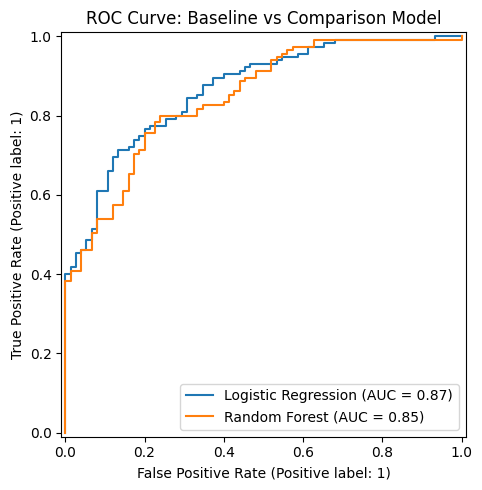

In [ ]:
fig, ax = plt.subplots(figsize=(6,5))
RocCurveDisplay.from_predictions(y_test, proba_b, name='Logistic Regression', ax=ax)
RocCurveDisplay.from_predictions(y_test, proba_r, name='Random Forest', ax=ax)
ax.set_title('ROC Curve: Baseline vs Comparison Model')
plt.tight_layout()
plt.show()

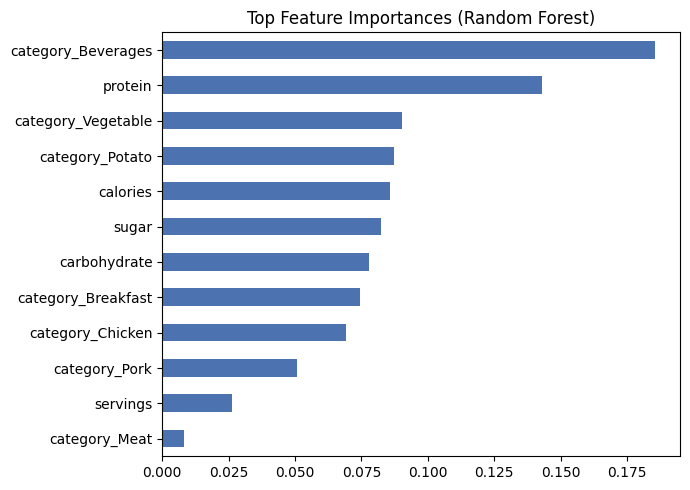

In [ ]:
ohe = rf.named_steps['prep'].named_transformers_['cat']
cat_names = list(ohe.get_feature_names_out(cat_features))
feat_names = num_features + cat_names
importances = rf.named_steps['clf'].feature_importances_
imp_series = pd.Series(importances, index=feat_names).sort_values(ascending=False).head(12)

fig, ax = plt.subplots(figsize=(7,5))
imp_series.plot(kind='barh', color='#4C72B0', ax=ax)
ax.invert_yaxis()
ax.set_title('Top Feature Importances (Random Forest)')
plt.tight_layout()
plt.show()

In [ ]:
print("Current estimate (5-fold CV, Logistic Regression):",
      round(cv_res_b['test_precision'].mean(),3), "+/-", round(cv_res_b['test_precision'].std(),3))
print("Target set by the Product Manager: 0.80")

Current estimate (5-fold CV, Logistic Regression): 0.8 +/- 0.043
Target set by the Product Manager: 0.80
